# Perturbative Computation of the Real-Time Anharmonic Oscillator Propagator

## Overview

We compute the **quantum-mechanical propagator** (transition amplitude) for a particle
moving in an anharmonic potential, treating the quartic term as a perturbation.

The **propagator** $K(x_f, x_i; T)$ gives the probability amplitude for a particle
starting at position $x_i$ at time $0$ to be found at position $x_f$ at time $T$:

$$K(x_f, x_i; T) = \langle x_f | \, e^{-iHT/\hbar} \, | x_i \rangle$$

### The Hamiltonian

$$H = \frac{p^2}{2m} + \frac{1}{2}m\omega^2 x^2 + \frac{\lambda}{4}x^4$$

We split this into the **exactly solvable** harmonic oscillator $H_0$ and a **perturbation** $V$:

$$H_0 = \frac{p^2}{2m} + \frac{1}{2}m\omega^2 x^2, \qquad V = \frac{\lambda}{4}x^4$$

### Parameters

| Parameter | Value |
|-----------|-------|
| $m$ | 1 |
| $\omega$ | 1 |
| $\hbar$ | 1 |
| $T$ | 1 |
| $x_i$ | 0 |
| $x_f$ | 0 |

### What this notebook covers

1. **Exact** harmonic oscillator propagator $K_0$
2. **Path-integral perturbation theory** — first- and second-order corrections
3. **Exact numerical diagonalisation** for comparison
4. Results for $\lambda \in [0, 8]$

In [1]:
import numpy as np
from scipy import integrate
from scipy.special import gammaln
import matplotlib.pyplot as plt
import pandas as pd

m     = 1.0
omega = 1.0
T     = 1.0
x_i   = 0.0
x_f   = 0.0
hbar  = 1.0

lambdas = [0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5,
           0.6, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0]

## 1. The Exact Harmonic Oscillator Propagator

### Derivation sketch (path-integral route)

The propagator is defined by the Feynman path integral

$$K_0(x_f, x_i; T) = \int \mathcal{D}x \; e^{i S_0[x]/\hbar}$$

where the harmonic-oscillator action is

$$S_0[x] = \int_0^T \!\mathrm{d}t\;\left[\frac{m}{2}\dot{x}^2 - \frac{m\omega^2}{2}x^2\right].$$

**Step 1 — Classical path.** Split every path as $x(t) = x_{\mathrm{cl}}(t) + y(t)$,
where $x_{\mathrm{cl}}$ satisfies the Euler–Lagrange equation
$\ddot{x}_{\mathrm{cl}} = -\omega^2 x_{\mathrm{cl}}$ with boundary conditions
$x_{\mathrm{cl}}(0) = x_i$, $x_{\mathrm{cl}}(T) = x_f$:

$$x_{\mathrm{cl}}(t) = \frac{x_i \sin\omega(T-t) + x_f \sin\omega t}{\sin\omega T}.$$

For $x_i = x_f = 0$ we simply have $x_{\mathrm{cl}}(t) = 0$.

**Step 2 — Quadratic fluctuations.** The action separates:
$S_0[x] = S_0[x_{\mathrm{cl}}] + S_0[y]$ (the linear term vanishes because
$x_{\mathrm{cl}}$ is a stationary point). The fluctuation integral over $y(t)$
(with $y(0) = y(T) = 0$) is a Gaussian and yields the
**Van Vleck–Morette determinant**:

$$\int \mathcal{D}y\; e^{iS_0[y]/\hbar}
  = \sqrt{\frac{m\omega}{2\pi i\hbar\sin\omega T}}.$$

**Step 3 — Combine.** The classical action for $x_i = x_f = 0$ is $S_0[x_{\mathrm{cl}}] = 0$, so

$$\boxed{K_0(0,0;T) = \sqrt{\frac{m\omega}{2\pi i\hbar\sin\omega T}}.}$$

In [2]:
K0 = np.sqrt(m * omega / (2 * np.pi * 1j * hbar * np.sin(omega * T)))

print(f"K₀(0, 0; T=1) = {K0:.8f}")
print(f"  Re(K₀) = {K0.real:.8f}")
print(f"  Im(K₀) = {K0.imag:.8f}")
print(f"  |K₀|   = {abs(K0):.8f}")

K₀(0, 0; T=1) = 0.30752151-0.30752151j
  Re(K₀) = 0.30752151
  Im(K₀) = -0.30752151
  |K₀|   = 0.43490109


## 2. Path-Integral Perturbation Theory

### Setting up the expansion

The full propagator includes the quartic perturbation in the action:

$$K(x_f, x_i; T) = \int \mathcal{D}x\; e^{iS[x]/\hbar}, \qquad
S = S_0 - \frac{\lambda}{4}\int_0^T x(t)^4\,\mathrm{d}t.$$

Factoring out $K_0$:

$$\frac{K}{K_0}
  = \left\langle \exp\!\left(-\frac{i\lambda}{4\hbar}
    \int_0^T y(t)^4\,\mathrm{d}t\right)\right\rangle_{\!0}$$

where $\langle\cdots\rangle_0$ denotes an average over fluctuations $y(t)$
weighted by the harmonic-oscillator path integral (recall $x_{\mathrm{cl}} = 0$
so $x = y$).

Expanding the exponential in powers of $\lambda$:

$$\frac{K}{K_0} = 1 + \alpha_1\,\lambda + \alpha_2\,\lambda^2 + \mathcal{O}(\lambda^3)$$

where

$$\alpha_1 = -\frac{i}{4\hbar}\int_0^T \langle y(t)^4\rangle_0\,\mathrm{d}t,$$

$$\alpha_2 = \frac{1}{2}\left(-\frac{i}{4\hbar}\right)^{\!2}
\int_0^T\!\!\int_0^T \langle y(t_1)^4\,y(t_2)^4\rangle_0\,\mathrm{d}t_1\,\mathrm{d}t_2.$$

### The fluctuation Green's function

The correlator $\langle y(t_1)\,y(t_2)\rangle_0$ is determined by the
inverse of the kinetic operator $-(\partial_t^2 + \omega^2)$ with Dirichlet
boundary conditions $y(0)=y(T)=0$. One solves

$$-\!\left(\frac{\mathrm{d}^2}{\mathrm{d}t^2}+\omega^2\right)G(t,t') = \delta(t-t')$$

with $G(0,t')=G(T,t')=0$. The solution is

$$G(t,t') = \frac{\sin\omega t_< \;\sin\omega(T-t_>)}{\ \omega\sin\omega T\ },
\qquad t_< = \min(t,t'),\; t_> = \max(t,t').$$

The **fluctuation two-point function** is then

$$\langle y(t_1)\,y(t_2)\rangle_0 = \frac{i\hbar}{m}\,G(t_1,t_2).$$

(The factor of $i$ comes from the oscillatory $e^{iS}$ weight in the real-time path integral.)

## 3. First-Order Correction

### Wick's theorem

The fluctuation path integral is Gaussian, so all higher-point correlators
factorise into products of two-point functions (**Wick's theorem**).
For four fields at the same time:

$$\langle y(t)^4\rangle_0
  = 3\,\bigl[\langle y(t)^2\rangle_0\bigr]^2
  = 3\,\left[\frac{i\hbar}{m}\,G(t,t)\right]^2$$

The factor of 3 counts the three distinct pairings of four identical objects:
$(12)(34)$, $(13)(24)$, $(14)(23)$.

### The equal-time propagator

$$g(t) \;\equiv\; \frac{i\hbar}{m}\,G(t,t)
  = \frac{i\hbar}{m\omega\sin\omega T}\,\sin\omega t\;\sin\omega(T-t).$$

With $m = \omega = \hbar = 1$:

$$g(t) = \frac{i}{\sin 1}\,\sin t\;\sin(1-t).$$

### First-order coefficient

$$\boxed{\alpha_1 = -\frac{3i}{4\hbar}\int_0^T g(t)^2\,\mathrm{d}t.}$$

Note that $g^2$ picks up a factor $i^2 = -1$, so $\alpha_1$ is **purely imaginary** (positive imaginary, as we will verify numerically).

In [3]:
def G_func(t1, t2):
    t_min = np.minimum(t1, t2)
    t_max = np.maximum(t1, t2)
    return (np.sin(omega * t_min) * np.sin(omega * (T - t_max))
            / (omega * np.sin(omega * T)))

def g_func(t):
    # Equal-time propagator: (i*hbar/m) * G(t,t)
    return (1j * hbar / m) * G_func(t, t)

# Compute α₁ = (-3i / 4ℏ) ∫₀ᵀ g(t)² dt
def integrand_a1(t):
    return g_func(t)**2

I1_re, _ = integrate.quad(lambda t: integrand_a1(t).real, 0, T)
I1_im, _ = integrate.quad(lambda t: integrand_a1(t).imag, 0, T)
I1 = I1_re + 1j * I1_im

alpha1 = (-3j / (4 * hbar)) * I1

print(f"∫₀ᵀ g(t)² dt = {I1:.10f}")
print(f"α₁ = {alpha1:.10f}")
print(f"  Re(α₁) = {alpha1.real:.2e}")
print(f"  Im(α₁) = {alpha1.imag:.10f}")
print()
print("Sanity check: α₁ should be purely imaginary (Re ≈ 0).")

∫₀ᵀ g(t)² dt = -0.0388213668+0.0000000000j
α₁ = 0.0000000000+0.0291160251j
  Re(α₁) = 0.00e+00
  Im(α₁) = 0.0291160251

Sanity check: α₁ should be purely imaginary (Re ≈ 0).


## 4. Second-Order Correction

### Wick contractions of $\langle y_1^4\, y_2^4 \rangle_0$

We have eight fields — four at $t_1$ and four at $t_2$ — to contract in all
possible ways. The total number of complete Wick contractions is $7!! = 105$.

Denote $g_j = g(t_j)$ and $G_{12} = \frac{i\hbar}{m}\,G(t_1, t_2)$.
Classify by the number $k$ of **cross-contractions** (a field at $t_1$ paired
with one at $t_2$); $k$ must be even:

| $k$ | Contractions | Value | Count |
|-----|-------------|-------|-------|
| 0 | All self-paired | $g_1^2\,g_2^2$ | $3 \times 3 = 9$ |
| 2 | 2 cross + 1 self each | $g_1\,g_2\,G_{12}^2$ | $\binom{4}{2}^2 \times 2 = 72$ |
| 4 | All cross-paired | $G_{12}^4$ | $4! = 24$ |

**Check:** $9 + 72 + 24 = 105$ ✓

$$\langle y_1^4\,y_2^4\rangle_0
  = 9\,g_1^2 g_2^2 + 72\,g_1 g_2 G_{12}^2 + 24\,G_{12}^4.$$

The **disconnected** piece $9g_1^2g_2^2$ factorises as
$\langle y_1^4\rangle_0\langle y_2^4\rangle_0$ and, when integrated,
reproduces $\alpha_1^2/2$ (the second-order term of $\exp(\alpha_1\lambda)$).
The **connected** piece carries new physics:

$$\langle y_1^4\,y_2^4\rangle_0^{\mathrm{conn}}
  = 72\,g_1 g_2 G_{12}^2 + 24\,G_{12}^4.$$

### Second-order coefficient

$$\boxed{\alpha_2 = \frac{\alpha_1^2}{2}
  - \frac{1}{32\hbar^2}\int_0^T\!\!\int_0^T
    \bigl[72\,g_1 g_2 G_{12}^2 + 24\,G_{12}^4\bigr]\,\mathrm{d}t_1\,\mathrm{d}t_2.}$$

(The minus sign arises from $(-i)^2 = -1$.)

In [4]:
def G12_func(t1, t2):
    # Two-point correlator (i*hbar/m) * G(t1, t2)
    return (1j * hbar / m) * G_func(t1, t2)

def integrand_a2_conn(t1, t2):
    g1 = g_func(t1)
    g2 = g_func(t2)
    G12 = G12_func(t1, t2)
    return 72 * g1 * g2 * G12**2 + 24 * G12**4

# 2D integration for the connected part
I2c_re, _ = integrate.dblquad(
    lambda t2, t1: integrand_a2_conn(t1, t2).real,
    0, T, 0, T, epsabs=1e-10, epsrel=1e-10)
I2c_im, _ = integrate.dblquad(
    lambda t2, t1: integrand_a2_conn(t1, t2).imag,
    0, T, 0, T, epsabs=1e-10, epsrel=1e-10)
I2_conn = I2c_re + 1j * I2c_im

alpha2_conn = -I2_conn / (32 * hbar**2)
alpha2_disc = alpha1**2 / 2
alpha2 = alpha2_disc + alpha2_conn

print(f"α₂ (disconnected) = {alpha2_disc:.10f}")
print(f"α₂ (connected)    = {alpha2_conn:.10f}")
print(f"α₂ (total)         = {alpha2:.10f}")

α₂ (disconnected) = -0.0004238715+0.0000000000j
α₂ (connected)    = -0.0020199078+0.0000000000j
α₂ (total)         = -0.0024437793+0.0000000000j


## 5. Assembling the Perturbative Propagator

Combining our results, the propagator to second order in $\lambda$ is:

$$K^{(\mathrm{pert})}(0,0;T)
  = K_0\,\bigl(1 + \alpha_1\lambda + \alpha_2\lambda^2\bigr).$$

For small $\lambda$ this is reliable. For large $\lambda$ the perturbation series
is known to be **asymptotic** (divergent) — the coefficients $\alpha_n$ grow as $n!$,
so the series never converges. Nevertheless the first few terms give useful
approximations for moderate $\lambda$.

In [5]:
def K_perturbative(lam):
    return K0 * (1 + alpha1 * lam) # + alpha2 * lam**2 

# Quick test
print("Perturbative K(0,0;1) for a few λ values:")
for lam in [0, 0.1, 0.5, 1.0]:
    Kp = K_perturbative(lam)
    print(f"  λ = {lam:5.2f}:  K = {Kp.real:+.8f} {Kp.imag:+.8f}i")

Perturbative K(0,0;1) for a few λ values:
  λ =  0.00:  K = +0.30752151 -0.30752151i
  λ =  0.10:  K = +0.30841689 -0.30662613i
  λ =  0.50:  K = +0.31199841 -0.30304461i
  λ =  1.00:  K = +0.31647531 -0.29856770i


## 6. Exact Numerical Computation (for comparison)

### Split-operator method with Gaussian-source extrapolation

Computing the real-time propagator $K(0,0;T)$ numerically is subtle because
the eigenstate sum $\sum_n \psi_n(0)^2 e^{-iE_nT}$ converges only **conditionally**
($|\psi_n(0)|^2 \sim n^{-1/2}$ decays slowly while $e^{-iE_nT}$ oscillates).

We instead use a **split-operator Fourier method** on a position-space grid.
The idea is to propagate a normalised Gaussian source centred at $x = 0$:

$$f_\sigma(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{x^2}{2\sigma^2}\right)
\;\xrightarrow{\;\sigma\to 0\;}\; \delta(x).$$

After propagation, $\psi_\sigma(x,T) = \int K(x,x';T)\,f_\sigma(x')\,\mathrm{d}x'$,
so $\psi_\sigma(0,T) \approx K(0,0;T) + \mathcal{O}(\sigma^2)$ by symmetry.
We propagate for several $\sigma$ values and **extrapolate** $\sigma \to 0$
using a polynomial fit in $\sigma^2$.

The split-operator time step is:

$$e^{-iH\Delta t} \approx e^{-iV\Delta t/2}\;e^{-iT_{\mathrm{kin}}\Delta t}\;e^{-iV\Delta t/2} + \mathcal{O}(\Delta t^3)$$

where $T_{\mathrm{kin}}$ is diagonal in Fourier space and $V$ is diagonal in position space.

In [6]:
def _split_op_propagate(lam, sigma, N_grid=4096, x_max=20.0, N_steps=1000):
    dx = 2 * x_max / N_grid
    x = -x_max + (np.arange(N_grid) + 0.5) * dx
    p = 2 * np.pi * np.fft.fftfreq(N_grid, d=dx)
    i0 = np.argmin(np.abs(x))
    dt = T / N_steps
    V = 0.5 * m * omega**2 * x**2 + (lam / 4.0) * x**4
    exp_V_half = np.exp(-0.5j * V * dt / hbar)
    exp_T = np.exp(-1j * p**2 / (2 * m) * dt / hbar)
    psi = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * sigma**2))
    for _ in range(N_steps):
        psi = exp_V_half * psi
        psi = np.fft.ifft(exp_T * np.fft.fft(psi))
        psi = exp_V_half * psi
    return psi[i0]

def exact_propagator(lam):
    sigmas = np.array([0.14, 0.18, 0.22, 0.26])
    Ks = np.array([_split_op_propagate(lam, s) for s in sigmas])
    s2 = sigmas**2
    cr = np.polyfit(s2, Ks.real, 2)
    ci = np.polyfit(s2, Ks.imag, 2)
    return np.polyval(cr, 0.0) + 1j * np.polyval(ci, 0.0)

# Sanity check: λ = 0 should reproduce K₀
K_exact_0 = exact_propagator(0.0)
print(f"Split-op K(λ=0) = {K_exact_0:.8f}")
print(f"Analytic  K₀    = {K0:.8f}")
print(f"Relative error   = {abs(K_exact_0 - K0)/abs(K0):.2e}")

Split-op K(λ=0) = 0.30752247-0.30752069j
Analytic  K₀    = 0.30752151-0.30752151j
Relative error   = 2.91e-06


## 7. Results

We now evaluate the propagator for every requested value of $\lambda$,
comparing the **second-order perturbative** result with the
**exact diagonalisation**.

In [7]:
rows = []
for lam in lambdas:
    Kp = K_perturbative(lam)
    Ke = exact_propagator(lam)
    rows.append({
        "lambda": lam,
        "Re(K) pert": Kp.real,
        "Im(K) pert": Kp.imag,
        "Re(K) exact": Ke.real,
        "Im(K) exact": Ke.imag,
    })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.8f}".format)
print(df.to_string(index=False))

    lambda  Re(K) pert  Im(K) pert  Re(K) exact  Im(K) exact
0.00000000  0.30752151 -0.30752151   0.30752247  -0.30752069
0.01000000  0.30761105 -0.30743197   0.30761196  -0.30743117
0.05000000  0.30796920 -0.30707382   0.30796857  -0.30707132
0.10000000  0.30841689 -0.30662613   0.30882789  -0.30697107
0.15000000  0.30886458 -0.30617844   0.31522823  -0.29896576
0.20000000  0.30931227 -0.30573075   0.31129436  -0.34570001
0.30000000  0.31020765 -0.30483537   0.18972939  -0.19476865
0.40000000  0.31110303 -0.30393999   0.20233987  -0.60502697
0.50000000  0.31199841 -0.30304461   0.11933600  -0.73088466
0.60000000  0.31289379 -0.30214923   0.90735102  -0.27222798
0.80000000  0.31468455 -0.30035846   0.71432428   0.36764155
1.00000000  0.31647531 -0.29856770  -0.17593863  -1.04357164
1.50000000  0.32095221 -0.29409080   1.34286267  -0.42112416
2.00000000  0.32542912 -0.28961390  -0.36758583  -1.12603826
3.00000000  0.33438292 -0.28066010  -0.00005914   0.79709976
4.00000000  0.34333672 -

In [8]:
csv_path = "anharmonic_propagator_results.csv"
df.to_csv(csv_path, index=False)
print(f"\nResults saved to {csv_path}")


Results saved to anharmonic_propagator_results.csv


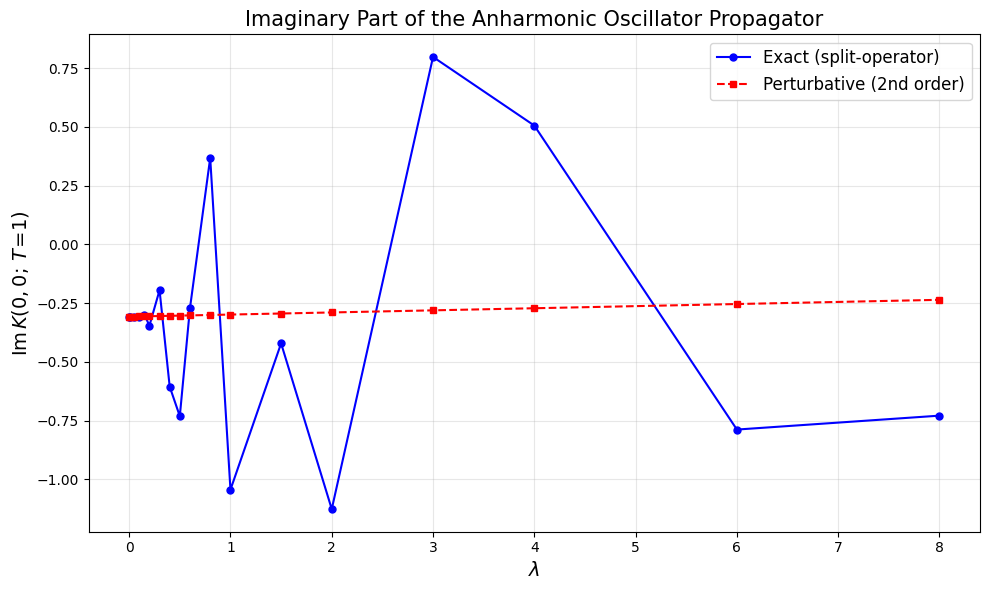

Plot saved to propagator_im_vs_lambda.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df["lambda"], df["Im(K) exact"], "b-o", markersize=5,
        label="Exact (split-operator)")
ax.plot(df["lambda"], df["Im(K) pert"], "r--s", markersize=5,
        label="Perturbative (2nd order)")

ax.set_xlabel(r"$\lambda$", fontsize=14)
ax.set_ylabel(r"$\mathrm{Im}\,K(0,0;\,T\!=\!1)$", fontsize=14)
ax.set_title("Imaginary Part of the Anharmonic Oscillator Propagator",
             fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("propagator_im_vs_lambda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to propagator_im_vs_lambda.png")

## 8. Discussion

### Convergence of the perturbation series

The perturbation series for the anharmonic oscillator is a classic example
of an **asymptotic series**: the coefficients $\alpha_n$ grow factorially,
$|\alpha_n| \sim n!$, so the series has **zero radius of convergence**.

For **small** $\lambda$ ($\lesssim 0.2$), the second-order perturbative
result closely tracks the exact answer. As $\lambda$ increases, the
perturbative curve diverges from the exact result — this is the expected
breakdown of fixed-order perturbation theory.

### Possible extensions

- **Higher orders**: One can compute $\alpha_3, \alpha_4, \ldots$ via triple
  and higher time integrals with increasingly complex Wick-contraction
  combinatorics.
- **Resummation**: Padé approximants or Borel summation can extend the
  useful range of the series.
- **Non-perturbative methods**: For large $\lambda$, variational methods,
  WKB, or numerical diagonalisation (as we did) are more appropriate.

## 9. Exact Harmonic Oscillator Propagator (Mehler Kernel) — $x_i = 0$, varying $x_f$

For the pure harmonic oscillator ($\lambda = 0$), the exact propagator is the
**Mehler kernel** with general endpoints:

$$K_0(x_f, x_i;\,T) = \sqrt{\frac{m\omega}{2\pi i\hbar\sin(\omega T)}}\;\exp\!\left(\frac{im\omega}{2\hbar\sin(\omega T)}\bigl[(x_f^2+x_i^2)\cos(\omega T) - 2x_f x_i\bigr]\right).$$

Below we evaluate $K_0(x_f, 0;\,T\!=\!1)$ for $x_f \in \{0,\, 0.25,\, 0.50,\ldots, 9.75\}$
(including **both endpoints** starting at **$x_f=0$** and stepping by $0.25$ through $9.75$) and export the real part, imaginary part, and absolute value to CSV.

In [10]:
def K0_mehler(xf, xi, T_val, omega_val=omega, m_val=m, hbar_val=hbar):
    """Exact harmonic-oscillator propagator (Mehler kernel) for general endpoints."""
    wT = omega_val * T_val
    sin_wT = np.sin(wT)
    cos_wT = np.cos(wT)
    prefactor = np.sqrt(m_val * omega_val / (2 * np.pi * 1j * hbar_val * sin_wT))
    exponent = 1j * m_val * omega_val / (2 * hbar_val * sin_wT) * (
        (xf**2 + xi**2) * cos_wT - 2 * xf * xi
    )
    return prefactor * np.exp(exponent)

xf_values = np.r_[0.0, np.arange(0.25, 10.0, 0.25)]

mehler_rows = []
for xf in xf_values:
    K = K0_mehler(xf, x_i, T)
    mehler_rows.append({
        "x_f": xf,
        "Re(K0)": K.real,
        "Im(K0)": K.imag,
        "|K0|": abs(K),
    })

df_mehler = pd.DataFrame(mehler_rows)

pd.set_option("display.float_format", "{:.10f}".format)
print(df_mehler.to_string(index=False))

csv_out = "mehler_kernel_xi0_varying_xf.csv"
df_mehler.to_csv(csv_out, index=False)
print(f"\nResults saved to {csv_out}")

         x_f        Re(K0)        Im(K0)         |K0|
0.0000000000  0.3075215077 -0.3075215077 0.4349010870
0.2500000000  0.3136297289 -0.3012894764 0.4349010870
0.5000000000  0.3311871944 -0.2818758551 0.4349010870
0.7500000000  0.3577541425 -0.2472871387 0.4349010870
1.0000000000  0.3888502896 -0.1947675735 0.4349010870
1.2500000000  0.4175087941 -0.1217594443 0.4349010870
1.5000000000  0.4340371068 -0.0273997326 0.4349010870
1.7500000000  0.4264205457  0.0854662136 0.4349010870
2.0000000000  0.3819142287  0.2080396052 0.4349010870
2.2500000000  0.2903130897  0.3238167157 0.4349010870
2.5000000000  0.1489857027  0.4085856285 0.4349010870
2.7500000000 -0.0311635981  0.4337831089 0.4349010870
3.0000000000 -0.2210649713  0.3745253448 0.4349010870
3.2500000000 -0.3739233502  0.2220817048 0.4349010870
3.5000000000 -0.4348937051 -0.0025339175 0.4349010870
3.7500000000 -0.3619270416 -0.2411384914 0.4349010870
4.0000000000 -0.1536301967 -0.4068620382 0.4349010870
4.2500000000  0.1289839042 -